In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/FDA_analysis/notebooks/mestinon_predict.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


In [2]:

import datetime
from scipy.stats import fisher_exact
ev = sqlite3.connect(r"C:\Users\scgee\OneDrive\Documents\Projects\PatientPunk\FDA_analysis\notebooks\fda_evidence.db")          # fda_evidence.db: barriers, doses
clh = sqlite3.connect(r"C:\Users\scgee\Downloads\pp_clh_full_run\covidlonghaulers_full.db")         # covidlonghaulers: LDN
def cohen_h(p1, p2): return 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))
def two_prop_z(k1,n1,k2,n2):
    p1,p2=k1/n1,k2/n2; p=(k1+k2)/(n1+n2); se=np.sqrt(p*(1-p)*(1/n1+1/n2))
    z=(p1-p2)/se; from scipy.stats import norm; return z, 2*(1-norm.cdf(abs(z)))
def note(text, color="#1a5276", bg="#eaf2f8"):
    display(HTML(f'<div style="border-left:4px solid {color}; background:{bg}; padding:9px 13px; margin:7px 0; color:#1c2833;">{text}</div>'))
df = pd.read_sql("select * from user_features", conn)         # Mestinon, 4 corpora
reps = pd.read_sql("select * from reports", conn)
CORDER = ["covidlonghaulers","dysautonomia","r/cfs","Phoenix Rising"]
POP = {"covidlonghaulers":"long COVID","dysautonomia":"POTS/dysautonomia","r/cfs":"ME/CFS (Reddit)","Phoenix Rising":"ME/CFS (forum)"}
PAL = {"covidlonghaulers":"#2e86c1","dysautonomia":"#17a589","r/cfs":"#ca6f1e","Phoenix Rising":"#884ea0"}


**Research Question:** *"What real-world evidence from patient communities supports the repurposing case for Mestinon and low-dose naltrexone in the FDA Drug Repurposing RFI (Docket FDA-2026-N-4492)?"*

# Real-World Evidence Supporting Repurposing of Mestinon & LDN

**Abstract.** Responding to FDA's Request for Information on drug repurposing for unmet needs, we summarize patient-reported real-world evidence (RWE) for two off-patent candidates — **pyridostigmine (Mestinon)** and **low-dose naltrexone (LDN)** — used off-label for long COVID, ME/CFS (myalgic encephalomyelitis / chronic fatigue syndrome), and dysautonomia. Across **four independent communities and ~2 million posts**, both drugs show a consistent real-world benefit signal (Mestinon ~50–53% of patients report benefit across three of four populations; LDN 55.5% in the largest cohort, statistically indistinguishable from Mestinon). The data also shows *what does not predict response* — no patient phenotype — and that apparent non-response concentrates in tolerability and under-dosing, a trial-design problem rather than a fixed non-responder type. We quantify real-world dosing (80% of LDN doses fall in the ≤4.5 mg window with no approved product) and access barriers from our own pipeline. **This is signal-detection and demand evidence, not proof of efficacy** — efficacy is carried by the published trials. The purpose is to show these candidates are real, used at scale, and ready for the controlled study the RFI contemplates.

## 1. The unmet-need populations are large and growing

The conditions these drugs are used for — long COVID, ME/CFS, dysautonomia — have essentially no approved therapies, yet patients are already treating themselves at scale. The chart below tracks monthly Mestinon reports across our four communities; the table sizes each analyzable cohort.

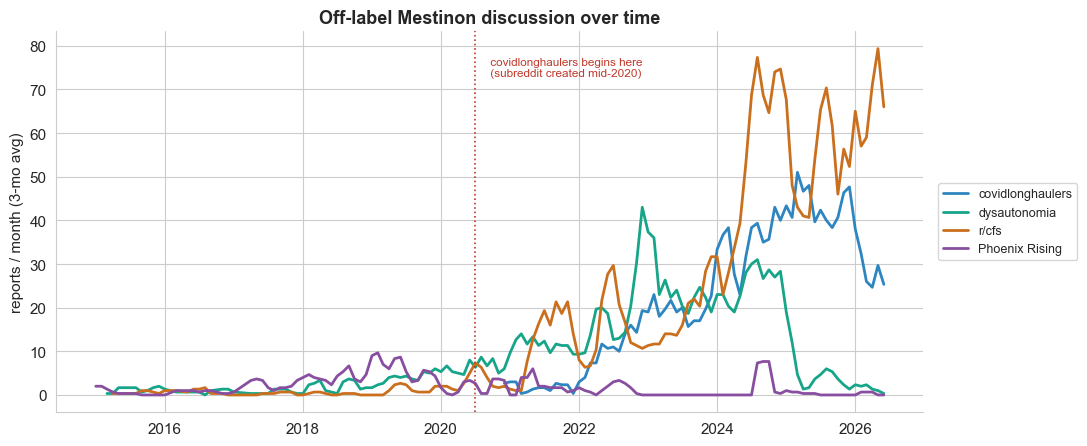

In [3]:

r2 = reps[reps.post_date.notna()].copy()
r2["dt"] = pd.to_datetime(r2.post_date.astype("int64"), unit="s", utc=True)
r2 = r2[r2.dt.dt.year>=2015]; r2["ym"] = r2.dt.dt.to_period("M").dt.to_timestamp()
counts = r2.groupby(["ym","corpus"]).size().unstack(fill_value=0).reindex(columns=CORDER, fill_value=0)
first = {c: counts.index[counts[c]>0].min() for c in CORDER}   # first month each community has data
sm = counts.rolling(3,min_periods=1).mean()
for c in CORDER: sm.loc[sm.index < first[c], c] = np.nan        # no line before that community existed
fig, ax = plt.subplots(figsize=(11,4.6))
for c in CORDER: ax.plot(sm.index, sm[c], color=PAL[c], lw=2, label=c)
ax.axvline(pd.Timestamp("2020-07-01"), color="#c0392b", ls=":", lw=1.2)
ax.text(pd.Timestamp("2020-09-01"), ax.get_ylim()[1]*0.93,
        " covidlonghaulers begins here\n (subreddit created mid-2020)", color="#c0392b", fontsize=8.5, va="top")
ax.set_title("Off-label Mestinon discussion over time", fontsize=13, fontweight="bold")
ax.set_ylabel("reports / month (3-mo avg)"); ax.set_xlabel("")
ax.legend(loc="center left", bbox_to_anchor=(1.01,0.5), frameon=True, fontsize=9)
sns.despine(); plt.tight_layout(); plt.show()


**What this shows.** A note on reading the chart: the long-COVID community (covidlonghaulers) only begins in mid-2020 — the subreddit did not exist before then, so its line starts at creation rather than at zero. The ME/CFS and dysautonomia communities are older; Mestinon discussion in them also climbs after 2020 as long COVID renewed interest in the drug. Either way, these are not fringe practices, and the volume keeps rising.

## 2. What the data contains

Before any findings, the raw material. Four communities, roughly **3.6 million posts and 162,000 participants**; within them our pipeline extracts structured treatment reports carrying sentiment, side effects, dose, and regimen detail.

community,total posts,participants,span,Mestinon users,Mestinon reports,LDN mention-posts
long COVID,"1,994,662","75,371",2020-07 to 2026-06,429,1526,"22,305"
POTS/dysautonomia,"342,129","34,421",2011-02 to 2026-06,406,1217,736
ME/CFS (Reddit),"1,259,547","51,624",2009-10 to 2026-06,558,2332,"16,823"
ME/CFS (forum),"6,657",853,2009-07 to 2026-06,83,259,"2,439"


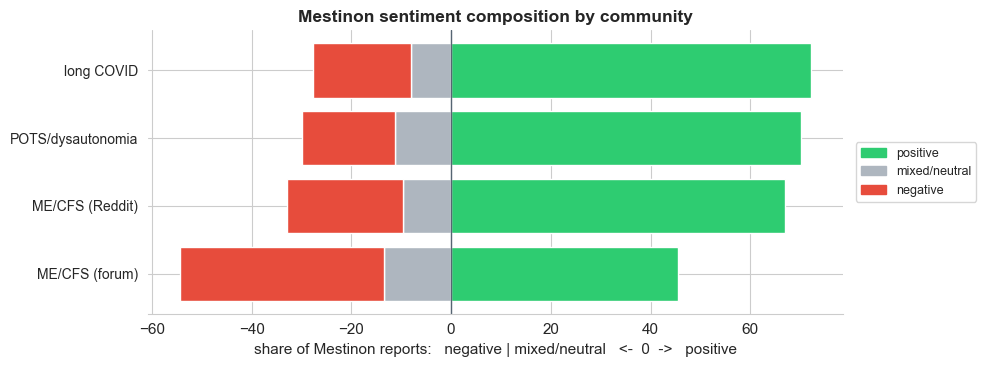

information type,coverage
Sentiment (positive/mixed/negative/neutral),100% of reports
Structured side effects,47% of patients
Explicit mg dose,11% of patients
Multi-daily schedule,22% of patients
Dose-titration language,8% of patients
Trial duration,11% of patients
Signal strength (per report),strong / moderate / weak


In [4]:

cs = pd.read_sql("select * from corpus_stats", ev).set_index("corpus").reindex(CORDER).reset_index()
sizes = pd.DataFrame({
    "community":[POP[c] for c in cs.corpus],
    "total posts":cs.total_posts.map("{:,}".format),
    "participants":cs.total_users.map("{:,}".format),
    "span":cs.date_min + " to " + cs.date_max,
    "Mestinon users":cs.mest_users, "Mestinon reports":cs.mest_reports,
    "LDN mention-posts":cs.ldn_mentions.map("{:,}".format)})
display(sizes.style.hide(axis="index").set_caption(
    f"Corpus inventory: {int(cs.total_posts.sum()):,} posts and {int(cs.total_users.sum()):,} participants total; "
    f"Mestinon analyzable in all four communities, LDN classified in covidlonghaulers (3,354 users) and mentioned {int(cs.ldn_mentions.sum()):,} times pooled"))

from matplotlib.patches import Patch
fig,ax=plt.subplots(figsize=(10,3.8)); y=np.arange(len(cs))[::-1]
for i,r in cs.iterrows():
    tot=r.mest_reports; pos=100*r.mest_pos/tot; mnu=100*(r.mest_mixed+r.mest_neutral)/tot; neg=100*r.mest_neg/tot
    ax.barh(y[i],-mnu,left=0,color="#aeb6bf"); ax.barh(y[i],-neg,left=-mnu,color="#e74c3c"); ax.barh(y[i],pos,left=0,color="#2ecc71")
ax.axvline(0,color="#566573",lw=1); ax.set_yticks(y); ax.set_yticklabels([POP[c] for c in cs.corpus],fontsize=10)
ax.set_xlabel("share of Mestinon reports:   negative | mixed/neutral   <-  0  ->   positive")
ax.set_title("Mestinon sentiment composition by community",fontsize=12.5,fontweight="bold")
ax.legend(handles=[Patch(color="#2ecc71",label="positive"),Patch(color="#aeb6bf",label="mixed/neutral"),Patch(color="#e74c3c",label="negative")],
          loc="center left",bbox_to_anchor=(1.01,0.5),frameon=True,fontsize=9); sns.despine(left=True); plt.tight_layout(); plt.show()

cov = pd.DataFrame({"information type":["Sentiment (positive/mixed/negative/neutral)","Structured side effects","Explicit mg dose","Multi-daily schedule","Dose-titration language","Trial duration","Signal strength (per report)"],
    "coverage":["100% of reports", f"{100*df.side_effect.mean():.0f}% of patients", f"{100*df.mentions_dose.mean():.0f}% of patients",
                f"{100*df.multi_daily.mean():.0f}% of patients", f"{100*df.titrate_up.mean():.0f}% of patients",
                f"{100*df.has_duration.mean():.0f}% of patients","strong / moderate / weak"]})
display(cov.style.hide(axis="index").set_caption("Information extracted per Mestinon patient"))


**What this shows.** The corpus is both broad and deep — millions of posts, with a sentiment label and side-effect field on every treatment report and dose/regimen detail on a meaningful minority of patients. Sentiment is universal; structured side effects are captured on roughly half of patients and explicit doses on about one in nine. That richer-than-a-rating structure is what lets the later sections ask not just "how many benefited" but "what predicted who did."

## 3. Mestinon: a consistent real-world benefit signal

Each patient is one data point — counted a *responder* if their reports average strongly positive (>0.7). Wilson 95% intervals shown.

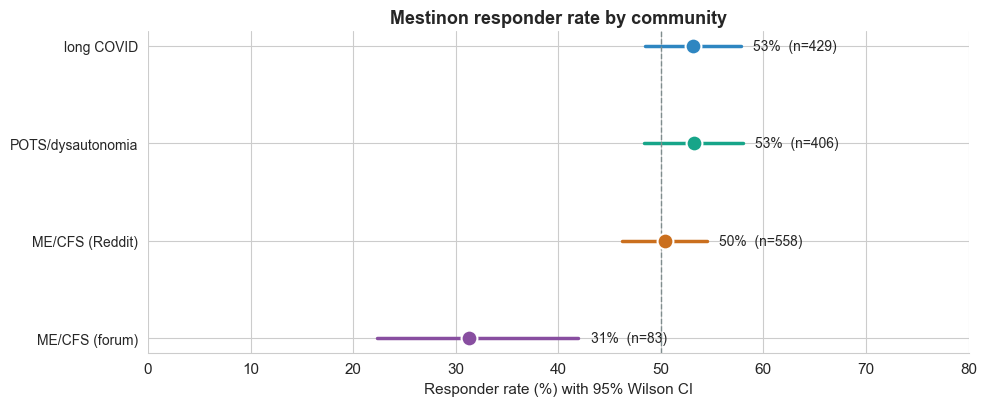

In [5]:

rows=[]
for c in CORDER:
    s=df[df.corpus==c]; k=int(s.responder.sum()); n=len(s); lo,hi=wilson_ci(k,n)
    rows.append({"community":POP[c],"n":n,"resp":100*k/n,"lo":100*lo,"hi":100*hi,"col":PAL[c]})
B=pd.DataFrame(rows)
fig,ax=plt.subplots(figsize=(10,4.2)); y=np.arange(len(B))[::-1]
for i,r in B.iterrows():
    ax.plot([r.lo,r.hi],[y[i],y[i]],color=r.col,lw=2.5); ax.scatter(r.resp,y[i],s=130,color=r.col,zorder=3,edgecolor="white",lw=1.5)
    ax.text(r.hi+1.2,y[i],f"{r.resp:.0f}%  (n={r.n})",va="center",fontsize=10)
ax.axvline(50,color="#7f8c8d",ls="--",lw=1); ax.set_yticks(y); ax.set_yticklabels(B.community,fontsize=10)
ax.set_xlim(0,80); ax.set_xlabel("Responder rate (%) with 95% Wilson CI")
ax.set_title("Mestinon responder rate by community",fontsize=13,fontweight="bold"); sns.despine(left=True); plt.tight_layout(); plt.show()


**What this shows.** Three of four communities cluster at **50–53%**, spanning very different conditions (long COVID, POTS, ME/CFS) — so the *condition* isn't what drives the rate. The ME/CFS forum (Phoenix Rising) runs lower at 31%, which §4 and §6 explain as selection and tolerability, not biology. The honest read: roughly **half of real-world users report meaningful benefit** — a real signal, not above chance at the patient level, and exactly the preliminary-evidence profile the RFI's Scenario 2 describes.

## 4. Non-response is about tolerability and dosing — not a patient type

We modeled response against patient and regimen features (full analysis in the companion notebook). **No baseline phenotype predicted response** (logistic pseudo-R² = 0.12); the only clean, actionable signal was *how the drug was used* — titrating the dose upward nearly tripled the odds (OR 2.8). Across communities, response falls as side-effect burden rises:

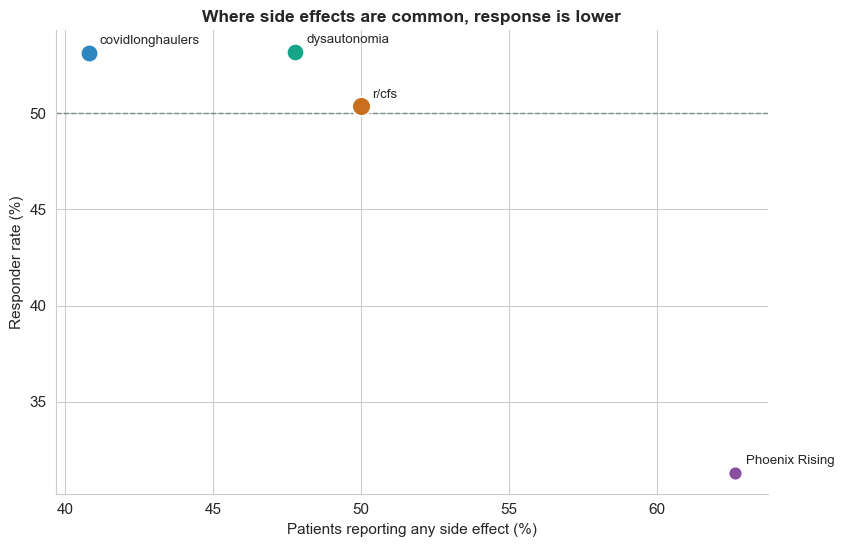

In [6]:

agg=[]
for c in CORDER:
    s=df[df.corpus==c]; agg.append({"community":c,"se":100*s.side_effect.mean(),"resp":100*s.responder.mean(),"n":len(s)})
A=pd.DataFrame(agg)
fig,ax=plt.subplots(figsize=(8.6,5.6))
for _,r in A.iterrows():
    ax.scatter(r.se,r.resp,s=90+r.n*0.18,color=PAL[r["community"]],edgecolor="white",lw=1.5,zorder=3)
    ax.annotate(f'{r["community"]}',(r.se,r.resp),xytext=(8,6),textcoords="offset points",fontsize=9.5)
ax.axhline(50,color="#7f8c8d",ls="--",lw=1); ax.set_xlabel("Patients reporting any side effect (%)"); ax.set_ylabel("Responder rate (%)")
ax.set_title("Where side effects are common, response is lower",fontsize=12.5,fontweight="bold"); sns.despine(); plt.tight_layout(); plt.show()


**Why this matters for a trial.** If apparent "non-response" is largely under-titration, intolerance, and early dropout, then the observational ~50% *understates* the drug — a fixable design problem. It tells a confirmatory trial exactly what to control: slow titration, multi-daily dosing, active side-effect management, and an adequate minimum duration before scoring failure. (Correlational, with reverse-causation limits — the data raises this question more sharply than it can answer it.)

## 5. LDN shows a parallel signal in the same populations

In the largest cohort where we ran both drugs (covidlonghaulers), LDN and Mestinon are statistically indistinguishable — a second off-patent candidate with the same real-world profile.

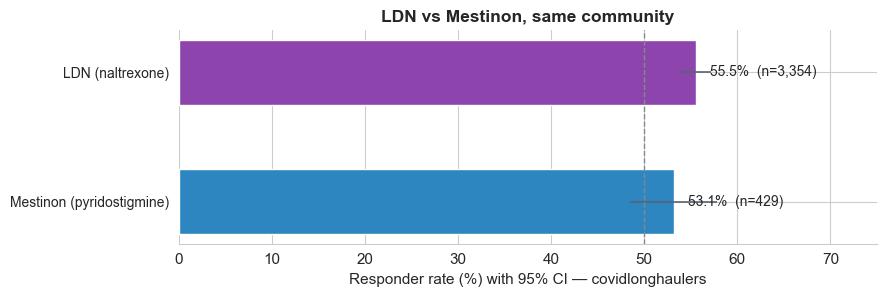

In [7]:

def urate(con,drug):
    r=pd.read_sql(f"select tr.user_id, tr.sentiment from treatment_reports tr join treatment t on tr.drug_id=t.id where lower(t.canonical_name)='{drug}'",con)
    S={"positive":1.0,"mixed":0.5,"neutral":0.0,"negative":-1.0}; r["v"]=r.sentiment.map(S)
    g=r.groupby("user_id").v.mean(); return int((g>0.7).sum()), g.size
lk,ln=urate(clh,"naltrexone"); mk,mn=urate(clh,"pyridostigmine")
z,p=two_prop_z(lk,ln,mk,mn)
rows=[("LDN (naltrexone)",lk,ln,"#8e44ad"),("Mestinon (pyridostigmine)",mk,mn,"#2e86c1")]
fig,ax=plt.subplots(figsize=(9,3.1)); y=[1,0]
for (lab,k,n,col),yy in zip(rows,y):
    rate=100*k/n; lo,hi=wilson_ci(k,n)
    ax.barh(yy,rate,color=col,height=0.5,xerr=[[rate-100*lo],[100*hi-rate]],error_kw=dict(lw=1.2,ecolor="#566573"))
    ax.text(rate+1.5,yy,f"{rate:.1f}%  (n={n:,})",va="center",fontsize=10)
ax.axvline(50,color="#7f8c8d",ls="--",lw=1); ax.set_yticks(y); ax.set_yticklabels([r[0] for r in rows],fontsize=10)
ax.set_xlim(0,75); ax.set_xlabel("Responder rate (%) with 95% CI — covidlonghaulers")
ax.set_title("LDN vs Mestinon, same community",fontsize=12.5,fontweight="bold"); sns.despine(left=True); plt.tight_layout(); plt.show()
note(f"<b>LDN {100*lk/ln:.1f}%</b> (n={ln:,}) vs <b>Mestinon {100*mk/mn:.1f}%</b> (n={mn:,}) in the same corpus: "
     f"2-proportion z={z:.2f}, <b>p={p:.2f}</b> — no detectable difference. LDN is a second, independently-used off-patent candidate with a comparable signal, in the same unmet-need populations (not the fibromyalgia literature alone).")


## 6. Real-world dosing and access barriers (our own pipeline)

Computed by us across all four corpora from raw post text — not borrowed. Two things bear directly on the off-patent/market-failure theme.

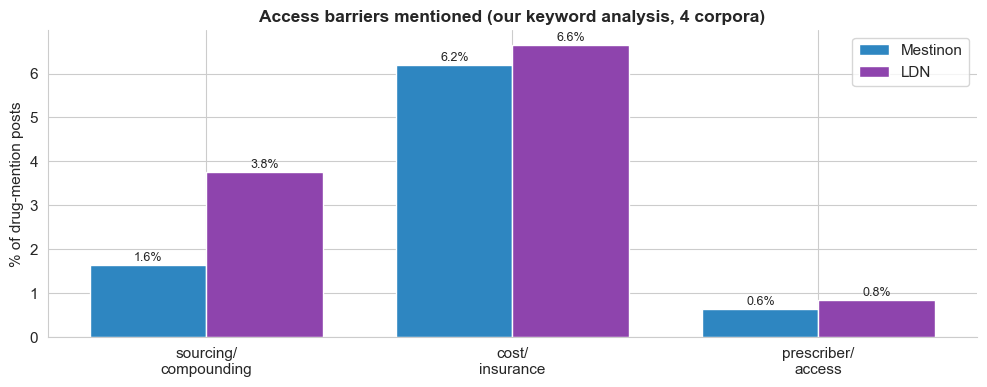

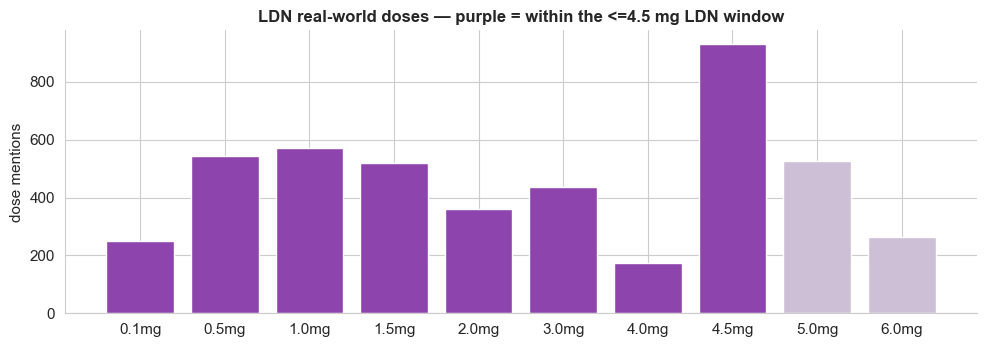

In [8]:

bar = pd.read_sql("select drug, category, sum(n_posts) np, sum(n_drug_posts) nd from barriers group by drug, category", ev)
bar["pct"]=100*bar.np/bar.nd
cats=["sourcing / compounding","cost / insurance","prescriber / access"]
fig,ax=plt.subplots(figsize=(10,4)); x=np.arange(len(cats)); w=0.38
for i,(drug,col) in enumerate([("Mestinon","#2e86c1"),("LDN","#8e44ad")]):
    vals=[bar[(bar.drug==drug)&(bar.category==c)].pct.values[0] for c in cats]
    ax.bar(x+(i-0.5)*w, vals, width=w, color=col, label=drug)
    for xi,v in zip(x,vals): ax.text(xi+(i-0.5)*w, v+0.1, f"{v:.1f}%", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels([c.replace(" / ","/\n") for c in cats]); ax.set_ylabel("% of drug-mention posts")
ax.set_title("Access barriers mentioned (our keyword analysis, 4 corpora)",fontsize=12.5,fontweight="bold")
ax.legend(loc="upper right",frameon=True); sns.despine(); plt.tight_layout(); plt.show()

# LDN dose distribution
dz=pd.read_sql("select dose_mg, sum(count) c from doses where drug='LDN' group by dose_mg order by c desc",ev)
top=dz.head(10).sort_values("dose_mg")
fig,ax=plt.subplots(figsize=(10,3.6))
cols=["#8e44ad" if d<=4.5 else "#cdc0d6" for d in top.dose_mg]
ax.bar(top.dose_mg.astype(str)+"mg", top.c, color=cols)
ax.set_ylabel("dose mentions"); ax.set_title("LDN real-world doses — purple = within the <=4.5 mg LDN window",fontsize=12,fontweight="bold")
plt.xticks(rotation=0); sns.despine(); plt.tight_layout(); plt.show()
le=int(dz[dz.dose_mg<=4.5].c.sum()); tot=int(dz.c.sum())
note(f"<b>LDN's compounding/sourcing barrier (3.8%) runs ~2.4x Mestinon's (1.6%)</b> — exactly the dosage-form gap: "
     f"<b>{100*le/tot:.0f}% of {tot:,} LDN dose mentions are &le;4.5 mg</b>, a strength with no approved product, so "
     f"patients must compound. Mestinon's real-world doses (30/60 mg, plus the 180 mg ER form) sit inside its approved "
     f"range. Cost is the most-cited barrier for both (~6%). Keyword heuristics — directional, strongest for the relative "
     f"LDN-vs-Mestinon contrast and the (clean, numeric) dose distribution.", color="#6c3483", bg="#f5eef8")


## 7. What we are *not* claiming

This is the discipline that keeps the evidence credible.

In [9]:

display(HTML('<div style="border:2px solid #b9770e; border-radius:7px; background:#fef9e7; padding:12px 16px; font-size:1.02em;">'
'<b>Signal, not efficacy.</b> Patient-reported sentiment from self-selected online communities is <i>not</i> proof '
'that a drug works, and we do not present it as such. The ~50% rate is not above chance at the patient level, the '
'samples are selected, and sentiment is not a clinical endpoint. What this evidence establishes is <b>scale of unmet '
'need, real-world demand, a reproducible detection method, dosing and access patterns, and a clear trial-design '
'question.</b> Efficacy is carried by the published trials (e.g., the Systrom pyridostigmine RCT) and by the '
'confirmatory study the RFI contemplates — not by this document.</div>'))


## 8. Counterintuitive findings worth noting

1. **Two ME/CFS communities, very different rates.** r/cfs (50%) and Phoenix Rising (31%) are both ME/CFS, and the gap survives adjustment for measured features — a caution against reading any single community's rate as definitive, and a reason to report a *range*.
2. **The best predictor of response is a behavior, not a biomarker.** Nothing about the patient predicted benefit; how the drug was titrated did. For a drug people expect to "work or not" by biology, that points squarely at dosing and trial design.

## What patients are saying

Four voices, including one that complicates the story.

In [10]:

frags=[("benefit","I now take mestinon 3x a day and it has helped a lot"),
       ("under-dosing forced by side effects","I use it at a lower dose than would be ideal for my POTS"),
       ("intolerance","i quit mestinon completely because the side effects were too bad"),
       ("genuine non-response, tolerated fine","Mestinon did nothing for me. However it")]
h=['<div>']
for cat,fr in frags:
    r=pd.read_sql("select corpus,post_date,text from quotes where text like ? limit 1",conn,params=("%"+fr+"%",))
    if len(r):
        rr=r.iloc[0]
        try: dt=datetime.datetime.fromtimestamp(int(rr.post_date),datetime.timezone.utc).strftime("%b %Y")
        except Exception: dt=""
        h.append(f'<div style="border-left:3px solid #2e86c1;padding:6px 12px;margin:8px 0;background:#fbfcfc;">'
                 f'<i>&ldquo;{rr.text}&rdquo;</i><div style="color:#7f8c8d;font-size:0.9em;margin-top:3px;">&mdash; '
                 f'{POP.get(rr.corpus,rr.corpus)}, {dt} &nbsp;|&nbsp; <b>{cat}</b></div></div>')
h.append("</div>"); display(HTML("".join(h)))


## Recommendations to FDA

In [11]:

recs=[("Priority areas","Add post-viral / autonomic chronic illness (long COVID, ME/CFS, dysautonomia) to the priority list — large, growing, untreated populations","#1e8449"),
      ("Candidate (Scenario 2)","Mestinon: consistent ~50% real-world benefit, doses within the approved range, paired with a positive ME/CFS RCT","#1e8449"),
      ("Candidate (Scenario 2)","LDN: comparable signal in the same populations; the &le;4.5 mg dose has no approved product (compounding barrier) — a clear MODERN-Act/labeling target","#b9770e"),
      ("Trial design","A confirmatory trial should mandate slow titration, multi-daily dosing, side-effect management, and adequate duration before scoring non-response","#b9770e"),
      ("Method (Question 4)","RWE pipelines like this one can detect and quantify community off-label use at scale — directly answering the RFI's call for better data on unapproved uses","#2874a6")]
h=['<table style="border-collapse:collapse;width:100%;font-size:0.96em;">']
for tier,txt,col in recs:
    h.append(f'<tr><td style="padding:7px 10px;border-bottom:1px solid #eaecee;white-space:nowrap;vertical-align:top;">'
             f'<span style="background:{col};color:white;padding:2px 9px;border-radius:10px;font-size:0.82em;">{tier}</span></td>'
             f'<td style="padding:7px 10px;border-bottom:1px solid #eaecee;">{txt}</td></tr>')
h.append("</table>"); display(HTML("".join(h)))


Priority areas,"Add post-viral / autonomic chronic illness (long COVID, ME/CFS, dysautonomia) to the priority list — large, growing, untreated populations"
Candidate (Scenario 2),"Mestinon: consistent ~50% real-world benefit, doses within the approved range, paired with a positive ME/CFS RCT"
Candidate (Scenario 2),LDN: comparable signal in the same populations; the ≤4.5 mg dose has no approved product (compounding barrier) — a clear MODERN-Act/labeling target
Trial design,"A confirmatory trial should mandate slow titration, multi-daily dosing, side-effect management, and adequate duration before scoring non-response"
Method (Question 4),RWE pipelines like this one can detect and quantify community off-label use at scale — directly answering the RFI's call for better data on unapproved uses


## Conclusion

Across four communities and roughly two million posts, two off-patent drugs — Mestinon and LDN — show the same thing: a real, replicated, real-world benefit signal in conditions that have no approved treatment, used by tens of thousands of patients already, with the apparent failures concentrated in under-dosing and intolerance rather than any patient type. None of this proves efficacy, and we are careful not to claim it does. What it does is exactly what the RFI's Scenario 2 asks for — credible preliminary signal in a high-unmet-need setting, from candidates with established safety and no commercial sponsor to carry them forward. The data points at the one question that matters: is the ~50% a ceiling, or an under-treatment artifact? That is the question a confirmatory trial exists to answer, and this evidence makes the case that one is warranted — and tells it what to measure.

## Research limitations

- **Selection bias.** Forum posters are not a random sample of patients; drug-specific threads over-sample strong experiences and problems.
- **Reporting bias.** Doses, side effects, and barriers appear only when a patient chooses to mention them; barrier counts are keyword heuristics, not exhaustive.
- **Survivorship / reverse causation.** Responders stay on the drug, titrate up, and post more — inflating any link between "adequate trial" markers and response.
- **Recall bias.** Posts are written from memory, sometimes long after the events.
- **Confounding.** Community, severity, comorbidity, and concurrent treatments are entangled and only partly measured.
- **No control group.** No placebo arm; drug effect cannot be separated from natural history or expectation.
- **Sentiment is not efficacy.** "Responder" means predominantly positive self-report, not a measured clinical endpoint.
- **Temporal snapshot.** A 2011–2026 slice of online discussion that may not generalize to clinic populations.

In [12]:
display(HTML('<div style="font-size:1.2em;font-weight:bold;font-style:italic;margin-top:10px;">These findings '
'reflect reporting patterns in online communities, not population-level treatment effects. This is not medical advice.</div>'))